In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import files

In [2]:
uploaded = files.upload()

Saving Ice Cream.csv to Ice Cream.csv


In [4]:
file_name = 'Ice Cream.csv'

df = pd.read_csv(file_name)

df.head()

,Temperature,Revenue
0,24.6,535
1,26.1,626
2,27.8,661
3,20.6,488
4,11.6,317


In [5]:
df.info()

df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 7.9 KB


,count,mean,std,min,25%,50%,75%,max
Temperature,500.0,22.2816,8.097597,0.0,17.175,22.4,27.8,45.0
Revenue,500.0,522.0580,175.410399,10.0,406.000,530.0,643.0,1000.0


In [6]:
df.isnull().sum()

,0
Temperature,0
Revenue,0


In [7]:
df = df.drop(columns=['Temparature (c)'], errors='ignore')

df.head()

,Temperature,Revenue
0,24.6,535
1,26.1,626
2,27.8,661
3,20.6,488
4,11.6,317


In [9]:
# target
y = df['Revenue']

# fitur
X = df.drop(columns=['Revenue'])

In [13]:
# Convert Revenue to a binary target variable (e.g., 0 for below median, 1 for above or equal to median)
median_revenue = df['Revenue'].median()
y = (df['Revenue'] >= median_revenue).astype(int)

In [11]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
model = Sequential()

# input layer + hidden layer 1
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

# hidden layer 2
model.add(Dense(16, activation='relu'))

# output layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [18]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5188 - loss: 0.6771 - val_accuracy: 0.4875 - val_loss: 0.6725
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5188 - loss: 0.6661 - val_accuracy: 0.5125 - val_loss: 0.6630
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5281 - loss: 0.6560 - val_accuracy: 0.5250 - val_loss: 0.6525
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5688 - loss: 0.6449 - val_accuracy: 0.5750 - val_loss: 0.6404
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5938 - loss: 0.6336 - val_accuracy: 0.5875 - val_loss: 0.6277
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6562 - loss: 0.6188 - val_accuracy: 0.6375 - val_loss: 0.6099
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6750 - loss: 0.6017 - val_accuracy: 0.6375 - val_loss: 0.5921
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7344 - loss: 0.5833 - val_accuracy: 0.7500 -

In [19]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy :", accuracy)
print("Loss :", loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9300 - loss: 0.1463 
Accuracy : 0.9300000071525574
Loss : 0.1462583690881729


In [20]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93        50
           1       0.98      0.88      0.93        50

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



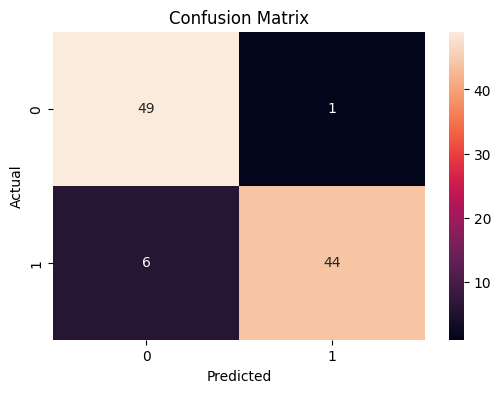

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

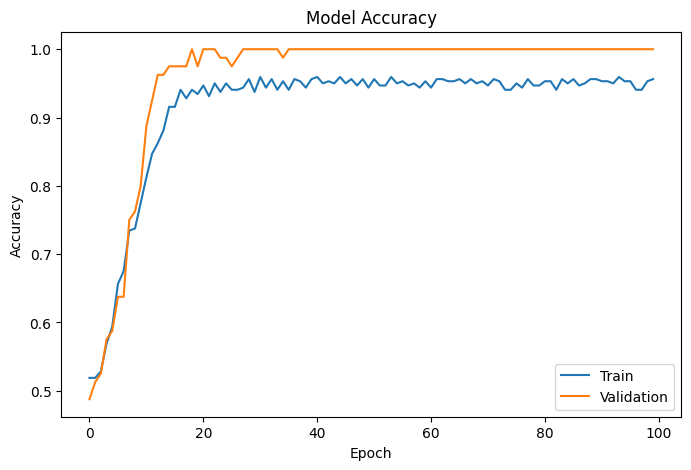

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

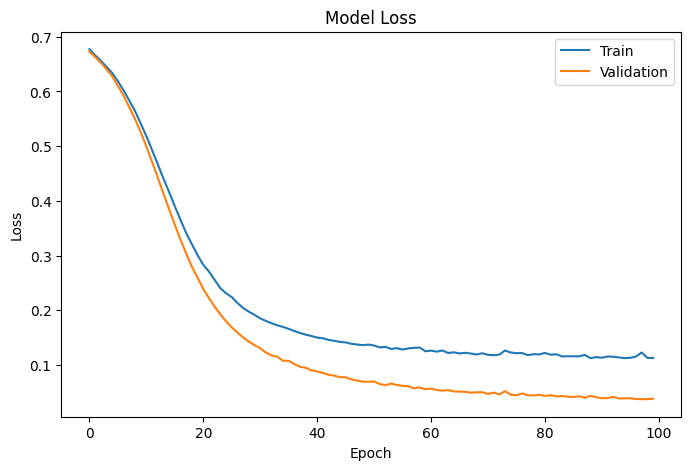

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

In [25]:
model.save('model_mlp.h5')

print("Model berhasil disimpan")

Model berhasil disimpan


In [26]:
hasil = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred.flatten()
})

hasil.to_excel(
    'hasil_prediksi.xlsx',
    index=False
)

print("File Excel berhasil disimpan")

File Excel berhasil disimpan


In [27]:
files.download('model_mlp.h5')

files.download('hasil_prediksi.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>